In [2]:
import cv2
import numpy as np
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt

In [3]:
img = cv2.imread("skeleton_black_on_white.png", cv2.IMREAD_GRAYSCALE)

print(img.shape, img.dtype)

(926, 1171) uint8


{'id': 1, 'conf': 0.767144, 'bbox_xyxy': (764, 753, 795, 782), 'endpoint_xy': (779, 768), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.767722, 'bbox_xyxy': (917, 303, 945, 329), 'endpoint_xy': (932, 316), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.787073, 'bbox_xyxy': (719, 314, 748, 343), 'endpoint_xy': (734, 329), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.790539, 'bbox_xyxy': (271, 777, 303, 807), 'endpoint_xy': (286, 791), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.805749, 'bbox_xyxy': (290, 330, 319, 359), 'endpoint_xy': (305, 344), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.835907, 'bbox_xyxy': (951, 733, 985, 769), 'endpoint_xy': (968, 751), 'method': 'cls1_center_snap_closest'}
{'id': 12, 'conf': 0.858931, 'bbox_xyxy': (175, 559, 388, 633), 'endpoint1_xy': (287, 558), 'endpoint2_xy': (284, 634), 'method': 'border_hits_farthest_pair'}
{'id': 9, 'conf': 0.89978, 'bbox_xyxy': (466, 283, 613, 355), 'endpoint1_

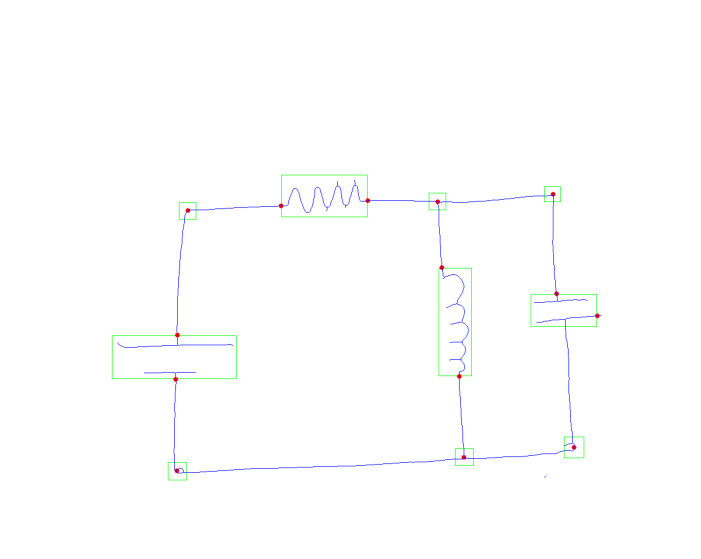

In [ ]:
import numpy as np
import cv2
from skimage.morphology import skeletonize

# ---------------- IO helpers ----------------
def load_yolo_detections(txt_path):
    """
    Each line: cls xc yc w h conf   (all normalized except cls/conf)
    """
    dets = []
    with open(txt_path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            parts = line.strip().split()
            cls = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            conf = float(parts[5]) if len(parts) > 5 else None
            dets.append((cls, xc, yc, w, h, conf))
    return dets

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int(round((xc - w/2) * W))
    y1 = int(round((yc - h/2) * H))
    x2 = int(round((xc + w/2) * W))
    y2 = int(round((yc + h/2) * H))
    x1 = max(0, min(W-1, x1))
    y1 = max(0, min(H-1, y1))
    x2 = max(0, min(W-1, x2))
    y2 = max(0, min(H-1, y2))
    if x2 < x1: x1, x2 = x2, x1
    if y2 < y1: y1, y2 = y2, y1
    return x1, y1, x2, y2

# ---------------- Skeleton / geometry helpers ----------------
_NEIGH8 = [(-1,-1), (-1,0), (-1,1),
           ( 0,-1),         ( 0,1),
           ( 1,-1), ( 1,0), ( 1,1)]

def count_neighbors(skel, y, x):
    H, W = skel.shape
    c = 0
    for dy, dx in _NEIGH8:
        yy, xx = y+dy, x+dx
        if 0 <= yy < H and 0 <= xx < W and skel[yy, xx]:
            c += 1
    return c

def farthest_pair(points_xy):
    """
    points_xy: (N,2) array of (x,y)
    returns (p1, p2) as arrays (2,)
    """
    if points_xy is None or len(points_xy) == 0:
        return None
    if len(points_xy) == 1:
        return points_xy[0], points_xy[0]
    diff = points_xy[:, None, :] - points_xy[None, :, :]
    d2 = (diff**2).sum(axis=2)
    i, j = np.unravel_index(np.argmax(d2), d2.shape)
    return points_xy[i], points_xy[j]

def skeleton_intersections_with_bbox_border(skel, x1, y1, x2, y2, tol=1):
    """
    Return skeleton pixels that lie on/near the bbox border (within tol pixels).
    """
    H, W = skel.shape
    xx1 = max(0, x1 - tol); yy1 = max(0, y1 - tol)
    xx2 = min(W-1, x2 + tol); yy2 = min(H-1, y2 + tol)

    band = np.zeros_like(skel, dtype=bool)
    band[yy1:yy2+1, xx1:xx2+1] = True

    # carve out interior (keep only border band)
    if (x2 - x1) > 2*tol and (y2 - y1) > 2*tol:
        band[y1+tol:y2-tol+1, x1+tol:x2-tol+1] = False

    ys, xs = np.where((skel > 0) & band)
    if len(xs) == 0:
        return np.empty((0,2), dtype=int)
    return np.stack([xs, ys], axis=1)

def reduce_border_hits_to_two_endpoints(skel, inter_xy):
    """
    inter_xy: (N,2) array of (x,y) skeleton pixels near bbox border.
    Choose 2 endpoints robustly (can be 2+ points).
    """
    if len(inter_xy) == 0:
        return None, None, "no_border_hits"

    # Prefer true endpoints among border hits (degree==1)
    eps = []
    for x, y in inter_xy:
        if count_neighbors(skel, y, x) == 1:
            eps.append((x, y))
    eps = np.array(eps, dtype=int)

    if len(eps) >= 2:
        p1, p2 = farthest_pair(eps)
        return tuple(map(int, p1)), tuple(map(int, p2)), "border_hits_endpoint_degree1"
    else:
        p1, p2 = farthest_pair(inter_xy)
        return tuple(map(int, p1)), tuple(map(int, p2)), "border_hits_farthest_pair"

# ---------------- Class 1 (single endpoint) helpers ----------------
def nearest_skeleton_point_with_dist(skel, anchor_xy, search_xyxy):
    """
    Find nearest skeleton pixel to anchor_xy within search box.
    Returns (point_xy, squared_distance) or (None, None).
    """
    x1,y1,x2,y2 = search_xyxy
    roi = skel[y1:y2+1, x1:x2+1]
    ys, xs = np.where(roi > 0)
    if len(xs) == 0:
        return None, None

    pts = np.stack([x1+xs, y1+ys], axis=1)  # (N,2)
    ax, ay = anchor_xy
    d2 = (pts[:,0]-ax)**2 + (pts[:,1]-ay)**2
    i = int(np.argmin(d2))
    return tuple(map(int, pts[i])), float(d2[i])

def endpoint_for_class1_single(skel, x1, y1, x2, y2, margin=8):
    """
    Return ONE point for cls==1:
    - Take center of bbox
    - Find closest skeleton pixel to that center (within bbox expanded by margin)
    - Return (point_xy, method) in same format as before
    """
    H, W = skel.shape
    xc = int(round((x1 + x2) / 2))
    yc = int(round((y1 + y2) / 2))

    # expand search region to allow snapping just outside bbox
    sx1 = max(0, x1 - margin); sy1 = max(0, y1 - margin)
    sx2 = min(W - 1, x2 + margin); sy2 = min(H - 1, y2 + margin)

    p, d2 = nearest_skeleton_point_with_dist(skel, (xc, yc), (sx1, sy1, sx2, sy2))
    if p is None:
        return None, "cls1_no_skeleton_found"

    return p, "cls1_center_snap_closest"


# ---------------- Main pipeline ----------------
def detect_endpoints(image_path, txt_path, thresh=128, border_tol=1, cls1_margin=8):
    """
    - Builds skeleton from image (black pixels are foreground)
    - For cls==1: returns ONE endpoint (snapped to skeleton)
    - For cls!=0 and cls!=1: returns TWO endpoints using bbox-border intersections
    """
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    H, W = gray.shape

    binary = (gray < thresh).astype(np.uint8)
    skel = skeletonize(binary.astype(bool)).astype(np.uint8)

    dets = load_yolo_detections(txt_path)
    results = []

    for cls, xc, yc, w, h, conf in dets:
        if cls == 0:
            continue  # skip 0 as requested

        x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, W, H)

        if cls == 1:
            ep, method = endpoint_for_class1_single(skel, x1, y1, x2, y2, margin=cls1_margin)
            results.append({
                "id": cls,
                "conf": conf,
                "bbox_xyxy": (x1, y1, x2, y2),
                "endpoint_xy": ep,
                "method": method
            })
        else:
            inter = skeleton_intersections_with_bbox_border(skel, x1, y1, x2, y2, tol=border_tol)

            if len(inter) == 0:
                # fallback: use farthest pair of all skeleton pixels inside bbox
                roi = skel[y1:y2+1, x1:x2+1]
                ys, xs = np.where(roi > 0)
                pts = np.stack([x1+xs, y1+ys], axis=1) if len(xs) else np.empty((0,2), dtype=int)
                fp = farthest_pair(pts)
                if fp is None:
                    p1 = p2 = None
                    method = "bbox_no_border_hit_no_skeleton"
                else:
                    p1, p2 = tuple(map(int, fp[0])), tuple(map(int, fp[1]))
                    method = "bbox_no_border_hit_fallback_farthest_in_bbox"
            else:
                p1, p2, method = reduce_border_hits_to_two_endpoints(skel, inter)

            results.append({
                "id": cls,
                "conf": conf,
                "bbox_xyxy": (x1, y1, x2, y2),
                "endpoint1_xy": p1,
                "endpoint2_xy": p2,
                "method": method
            })

    return results, skel

# ---------------- Optional visualization ----------------
def visualize_results(image_path, results, skel=None, draw_skeleton=False):
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    for r in results:
        x1,y1,x2,y2 = r["bbox_xyxy"]
        cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 1)

        if "endpoint_xy" in r:
            p = r["endpoint_xy"]
            if p is not None:
                cv2.circle(vis, p, 4, (0,0,255), -1)
        else:
            for k in ["endpoint1_xy", "endpoint2_xy"]:
                p = r.get(k, None)
                if p is not None:
                    cv2.circle(vis, p, 4, (0,0,255), -1)

    if draw_skeleton and skel is not None:
        ys, xs = np.where(skel > 0)
        vis[ys, xs] = (255, 0, 0)

    plt.figure(figsize=(12,7))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


# ---------------- Example usage ----------------
image_path = "skeleton_black_on_white.png"  # <-- set this
txt_path = "/Users/mac/Downloads/LineDetect/ImageData/Imgtotest.txt"

results, skel = detect_endpoints(
    image_path=image_path,
    txt_path=txt_path,
    thresh=128,
    border_tol=1,
    cls1_margin=8
)

for r in results:
    print(r)

visualize_results(image_path, results, draw_skeleton=True, skel=skel)



In [6]:
def extract_all_endpoints(results):
    """
    Extract all unique endpoints from results.
    Returns a list of (x, y) tuples.
    """
    endpoints = []
    for r in results:
        if "endpoint_xy" in r and r["endpoint_xy"] is not None:
            endpoints.append(r["endpoint_xy"])
        if "endpoint1_xy" in r and r["endpoint1_xy"] is not None:
            endpoints.append(r["endpoint1_xy"])
        if "endpoint2_xy" in r and r["endpoint2_xy"] is not None:
            endpoints.append(r["endpoint2_xy"])
    # Remove duplicates while preserving order
    seen = set()
    unique = []
    for ep in endpoints:
        if ep not in seen:
            seen.add(ep)
            unique.append(ep)
    return unique

In [7]:
arrayendpoints2 = extract_all_endpoints(results)
print("All extracted endpoints:", arrayendpoints2)

All extracted endpoints: [(779, 768), (932, 316), (734, 329), (286, 791), (305, 344), (968, 751), (287, 558), (284, 634), (614, 327), (465, 336), (741, 442), (771, 629), (938, 487), (1008, 525)]


In [8]:
from collections import deque
import numpy as np

# ---------------- Helpers ----------------

def get_neighbors8(y, x, H, W):
    """Return list of valid 8-connected neighbor coordinates (y, x)."""
    neighbors = []
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            if dy == 0 and dx == 0:
                continue
            ny, nx = y + dy, x + dx
            if 0 <= ny < H and 0 <= nx < W:
                neighbors.append((ny, nx))
    return neighbors

def disk_mask(radius):
    """
    Return a list of (dy, dx) offsets for a filled disk of given radius.
    Includes center (0,0).
    """
    offsets = []
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            if dy * dy + dx * dx <= radius * radius:
                offsets.append((dy, dx))
    return offsets

def build_node_id_map(skel, nodes, radius=3):
    """
    Build a node_id_map image where each pixel is:
      - node index i if within radius of node i
      - -1 otherwise
    
    Args:
        skel: (H, W) skeleton array
        nodes: list of (x, y) node coordinates
        radius: disk radius around each node
    
    Returns:
        node_id_map: (H, W) int array, -1 for non-node pixels
    """
    H, W = skel.shape
    node_id_map = np.full((H, W), -1, dtype=np.int32)
    
    disk = disk_mask(radius)
    
    for i, (nx, ny) in enumerate(nodes):
        for dy, dx in disk:
            py, px = ny + dy, nx + dx
            if 0 <= py < H and 0 <= px < W:
                node_id_map[py, px] = i
    
    return node_id_map

def bfs_neighbors_for_node(node_idx, nodes, skel, node_id_map, radius=3):
    """
    BFS from node node_idx along skeleton pixels.
    Stop each branch when hitting another node.
    
    Returns:
        set of neighbor node indices
    """
    H, W = skel.shape
    nx, ny = nodes[node_idx]
    
    neighbors_found = set()
    
    # Visited array for this BFS (pixel-level)
    visited = np.zeros((H, W), dtype=bool)
    
    # Mark the starting node's disk region as visited (to avoid self-hits)
    disk = disk_mask(radius)
    for dy, dx in disk:
        py, px = ny + dy, nx + dx
        if 0 <= py < H and 0 <= px < W:
            visited[py, px] = True
    
    # Initialize queue with skeleton pixels at the edge of the node's disk
    # These are pixels adjacent to the disk that are on the skeleton
    queue = deque()
    
    for dy, dx in disk:
        py, px = ny + dy, nx + dx
        if 0 <= py < H and 0 <= px < W:
            # Check 8-neighbors of this disk pixel
            for npy, npx in get_neighbors8(py, px, H, W):
                if not visited[npy, npx] and skel[npy, npx] > 0:
                    visited[npy, npx] = True
                    queue.append((npy, npx))
    
    # BFS
    while queue:
        cy, cx = queue.popleft()
        
        # Check if this pixel is part of another node
        other_node = node_id_map[cy, cx]
        if other_node != -1 and other_node != node_idx:
            # Found a neighbor node - record it and stop this branch
            neighbors_found.add(other_node)
            continue  # Do NOT enqueue neighbors from this pixel
        
        # Continue BFS: enqueue skeleton neighbors
        for npy, npx in get_neighbors8(cy, cx, H, W):
            if not visited[npy, npx] and skel[npy, npx] > 0:
                visited[npy, npx] = True
                queue.append((npy, npx))
    
    return neighbors_found

def build_adjacency(skel, nodes, radius=3):
    """
    Build adjacency dict from skeleton and node list.
    
    Args:
        skel: (H, W) skeleton array
        nodes: list of (x, y) node coordinates
        radius: disk radius for node detection
    
    Returns:
        adjacency: dict[int, set[int]] - undirected graph adjacency
    """
    print(f"Building adjacency for {len(nodes)} nodes with radius={radius}...")
    
    # Build node_id_map
    node_id_map = build_node_id_map(skel, nodes, radius)
    
    # Initialize adjacency
    adjacency = {i: set() for i in range(len(nodes))}
    
    # BFS from each node
    for i in range(len(nodes)):
        neighbors = bfs_neighbors_for_node(i, nodes, skel, node_id_map, radius)
        for j in neighbors:
            adjacency[i].add(j)
            adjacency[j].add(i)  # Undirected
    
    return adjacency

# ---------------- Build adjacency ----------------
adjacency = build_adjacency(skel, arrayendpoints2, radius=3)

# ---------------- Print adjacency ----------------
print("\n=== Node Adjacency ===")
for i, neighbors in adjacency.items():
    node_coord = arrayendpoints2[i]
    neighbor_strs = [f"{j} {arrayendpoints2[j]}" for j in sorted(neighbors)]
    print(f"Node {i} {node_coord}: -> {neighbor_strs}")

print(f"\n=== Summary ===")
total_edges = sum(len(n) for n in adjacency.values()) // 2
print(f"Total nodes: {len(adjacency)}")
print(f"Total edges: {total_edges}")

# Check connectivity
from collections import deque as dq
def count_components(adj):
    visited = set()
    components = 0
    for start in adj:
        if start not in visited:
            components += 1
            q = dq([start])
            while q:
                node = q.popleft()
                if node in visited:
                    continue
                visited.add(node)
                for neighbor in adj[node]:
                    if neighbor not in visited:
                        q.append(neighbor)
    return components

num_components = count_components(adjacency)
print(f"Connected components: {num_components}")

Building adjacency for 14 nodes with radius=3...

=== Node Adjacency ===
Node 0 (779, 768): -> ['3 (286, 791)', '5 (968, 751)', '11 (771, 629)']
Node 1 (932, 316): -> ['2 (734, 329)', '12 (938, 487)']
Node 2 (734, 329): -> ['1 (932, 316)', '8 (614, 327)', '10 (741, 442)']
Node 3 (286, 791): -> ['0 (779, 768)', '7 (284, 634)']
Node 4 (305, 344): -> ['6 (287, 558)', '9 (465, 336)']
Node 5 (968, 751): -> ['0 (779, 768)', '13 (1008, 525)']
Node 6 (287, 558): -> ['4 (305, 344)']
Node 7 (284, 634): -> ['3 (286, 791)']
Node 8 (614, 327): -> ['2 (734, 329)', '9 (465, 336)']
Node 9 (465, 336): -> ['4 (305, 344)', '8 (614, 327)']
Node 10 (741, 442): -> ['2 (734, 329)', '11 (771, 629)']
Node 11 (771, 629): -> ['0 (779, 768)', '10 (741, 442)']
Node 12 (938, 487): -> ['1 (932, 316)']
Node 13 (1008, 525): -> ['5 (968, 751)']

=== Summary ===
Total nodes: 14
Total edges: 13
Connected components: 1


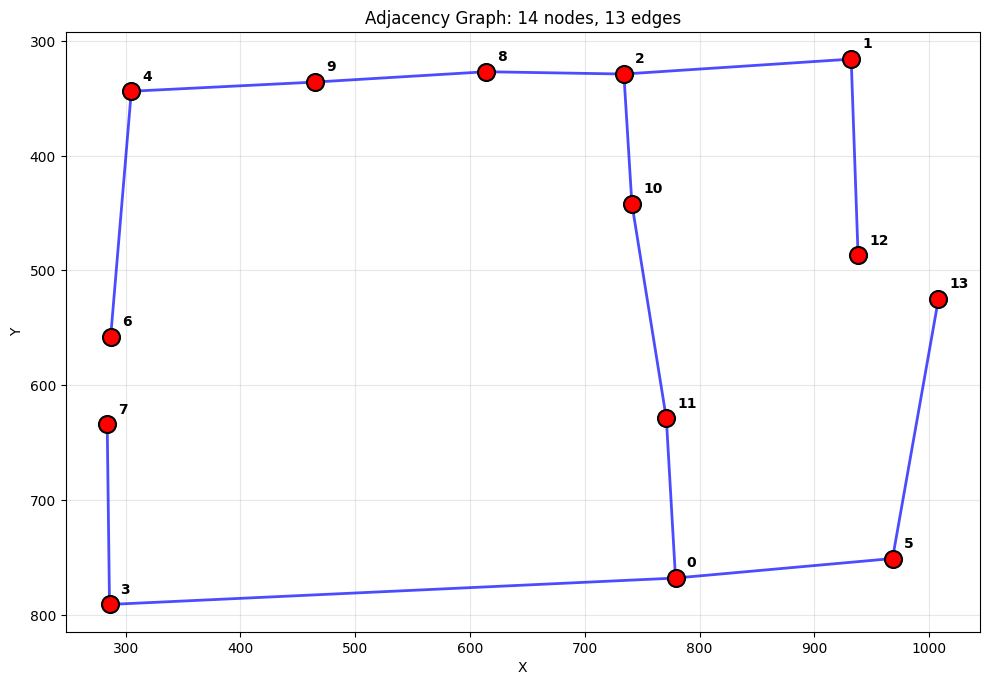

In [9]:
# ---------------- Visualize adjacency graph with raw lines ----------------
import matplotlib.pyplot as plt

def plot_adjacency_graph(nodes, adjacency, figsize=(10, 10)):
    """
    Plot the adjacency graph as raw lines on a blank canvas.
    
    Args:
        nodes: list of (x, y) node coordinates
        adjacency: dict[int, set[int]] adjacency
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw edges
    drawn_edges = set()
    for i, neighbors in adjacency.items():
        x1, y1 = nodes[i]
        for j in neighbors:
            # Avoid drawing same edge twice
            edge = tuple(sorted([i, j]))
            if edge in drawn_edges:
                continue
            drawn_edges.add(edge)
            
            x2, y2 = nodes[j]
            ax.plot([x1, x2], [y1, y2], 'b-', linewidth=2, alpha=0.7)
    
    # Draw nodes
    xs = [n[0] for n in nodes]
    ys = [n[1] for n in nodes]
    ax.scatter(xs, ys, s=150, c='red', zorder=5, edgecolors='black', linewidths=1.5)
    
    # Label nodes
    for i, (x, y) in enumerate(nodes):
        ax.annotate(str(i), (x, y), textcoords="offset points", 
                    xytext=(8, 8), fontsize=10, fontweight='bold')
    
    # Invert y-axis to match image coordinates (origin top-left)
    ax.invert_yaxis()
    
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Adjacency Graph: {len(nodes)} nodes, {len(drawn_edges)} edges')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot the adjacency graph
plot_adjacency_graph(arrayendpoints2, adjacency)